In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import neurokit2 as nk
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller


In [4]:
import wfdb
from scipy.signal import butter, filtfilt
import neurokit2 as nk

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:,0]
fs = record.fs

def bandpass(sig, fs, low=0.5, high=40):
    nyq = fs/2
    b,a = butter(4, [low/nyq, high/nyq], btype="band")
    return filtfilt(b,a,sig)

filtered = bandpass(signal, fs)

signals, info = nk.ecg_process(filtered, sampling_rate=fs)
rpeaks = info["ECG_R_Peaks"]

rr = np.diff(rpeaks)/fs
hr = 60/rr
t_hr = rpeaks[1:]/fs

hr_series = pd.Series(hr, index=pd.to_timedelta(t_hr, unit="s"))

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\neurokit2\epochs\epochs_create.py:180: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude=["int", "int64"]).replace({0.0: np.nan}, inplace=True)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\neurokit2\epochs\epoch

In [5]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(hr, lags=1).fit()
print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                 2270
Model:                     AutoReg(1)   Log Likelihood               -5537.168
Method:               Conditional MLE   S.D. of innovations              2.777
Date:                Wed, 04 Mar 2026   AIC                          11080.335
Time:                        16:10:29   BIC                          11097.517
Sample:                             1   HQIC                         11086.604
                                 2270                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.9118      1.202     21.552      0.000      23.555      28.268
y.L1           0.6577      0.016     41.445      0.000       0.627       0.689
                                    Roots           

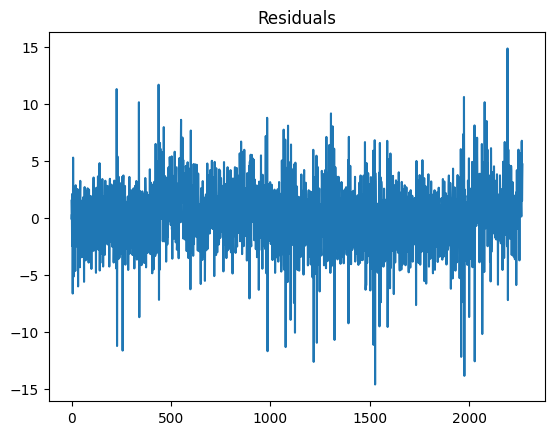

In [6]:
residuals = model.resid

import matplotlib.pyplot as plt
plt.plot(residuals)
plt.title("Residuals")
plt.show()

In [7]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(residuals, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,737.252632,6.287594e-152


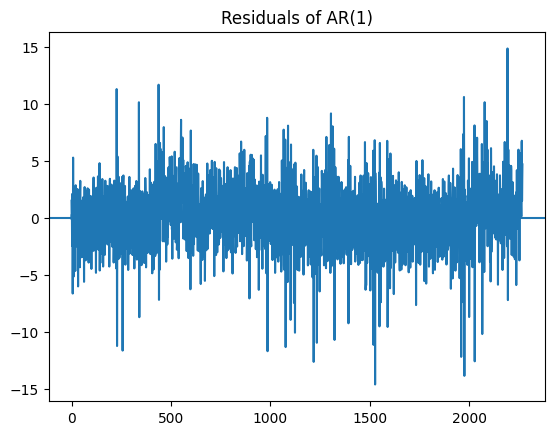

In [8]:
plt.figure()
plt.plot(residuals)
plt.title("Residuals of AR(1)")
plt.axhline(0)
plt.show()

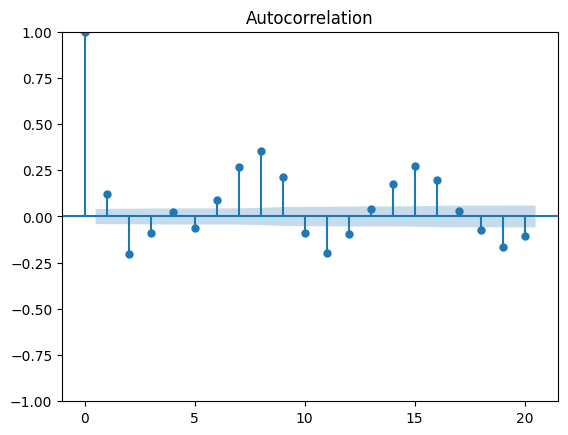

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20)
plt.show()

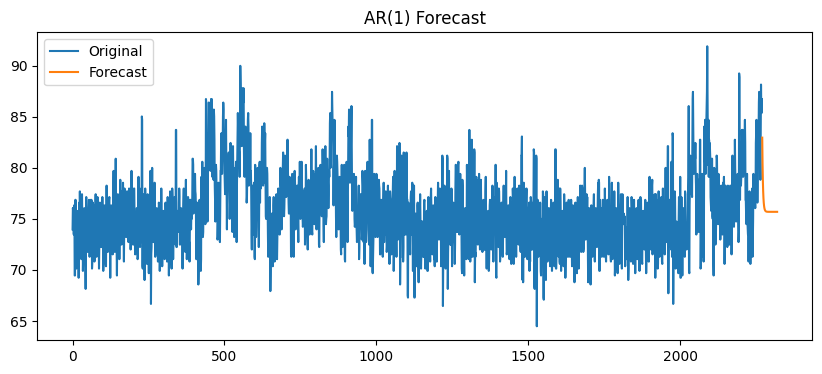

In [18]:
forecast = model.forecast(steps=50)

plt.figure(figsize=(10,4))
plt.plot(hr, label="Original")
plt.plot(range(len(hr), len(hr)+50), forecast, label="Forecast")
plt.legend()
plt.title("AR(1) Forecast")
plt.show()